In [1]:
# Imports
from nltk.corpus import movie_reviews
import random
import pandas as pd
from collections import Counter
from math import log
import seaborn as sns
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, WordPunctTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from nltk.stem import WordNetLemmatizer
import nltk
import numpy as np
from nltk.classify import NaiveBayesClassifier
from nltk.classify import accuracy
from transformers import pipeline
from datasets import load_dataset
import google.generativeai as genai
import time
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')   
nltk.download("omw-1.4")
nltk.download("punkt_tab")

from sklearn.model_selection import train_test_split


c:\Users\gavri\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\gavri\AppData\Local\Temp\ipykernel_21572\2322144356.py:21: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gavri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gavri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-

In [2]:
df = pd.read_csv('final_results_long_format.csv')

In [3]:
df['writer']=df['writer'].str.replace('answer_gemini', 'gemini_answers')

In [4]:
df.head()

,source,question,answer,writer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers


In [5]:
df['question_clean'] = (
    df['question']
    .str.replace(r'\\n|\\r', ' ', regex=True)
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.replace(r'^\\+\s*|^\s*[\["\']+|[\]"\']+\s*$', '', regex=True)
    .str.replace(r'\s{2,}', ' ', regex=True)
)

df['question_clean'] = df['question_clean'].str.replace(r'^\\+\s*', '', regex=True)

In [6]:
df['answer_clean'] = (
    df['answer']
    .str.replace(r'\\n|\\r', ' ', regex=True)
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.replace(r'^\\+\s*|^\s*[\["\']+|[\]"\']+\s*$', '', regex=True)
    .str.replace(r'\s{2,}', ' ', regex=True)
)

df['answer_clean'] = df['answer_clean'].str.replace(r'^\\+\s*', '', regex=True)

In [7]:
df.head(20)

,source,question,answer,writer,question_clean,answer_clean
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens..."
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ..."
5,reddit_eli5,How can observing something change the outcome...,Imagine you have a box with a toy inside. You...,gemini_answers,How can observing something change the outcome...,Imagine you have a box with a toy inside. You ...
6,finance,Loan for car buy “cash” (third party) or bank ...,"[""The car dealership doesn't care where you ge...",human_answers,Loan for car buy “cash” (third party) or bank ...,The car dealership doesn't care where you get ...
7,finance,Judge market efficiency from raw price action,Judging market efficiency solely from raw pric...,gemini_answers,Judge market efficiency from raw price action,Judging market efficiency solely from raw pric...
8,reddit_eli5,"How can a drink taste "" dry "" ? I really enjoy...",Imagine you're eating a candy. Some candies a...,gemini_answers,"How can a drink taste "" dry "" ? I really enjoy...",Imagine you're eating a candy. Some candies ar...
9,reddit_eli5,How effective would martial arts be in a real ...,"[""Martial arts can be effective in a street fi...",chatgpt_answers,How effective would martial arts be in a real ...,Martial arts can be effective in a street figh...


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['answer'])
tfidf_scores = tfidf_matrix.mean(axis=1)

In [9]:
df.head()

,source,question,answer,writer,question_clean,answer_clean
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens..."
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ..."


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

question_vecs = vectorizer.fit_transform(df['question'])
answer_vecs = vectorizer.transform(df['answer_clean'])

df['cosine_sim_answer_question'] = [
    cosine_similarity(question_vecs[i], answer_vecs[i])[0][0]
    for i in range(len(df))
]

In [11]:
df.head()

,source,question,answer,writer,question_clean,answer_clean,cosine_sim_answer_question
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...,0.217907
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens...",0.019536
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...,0.084541
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...,0.142301
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ...",0.126231


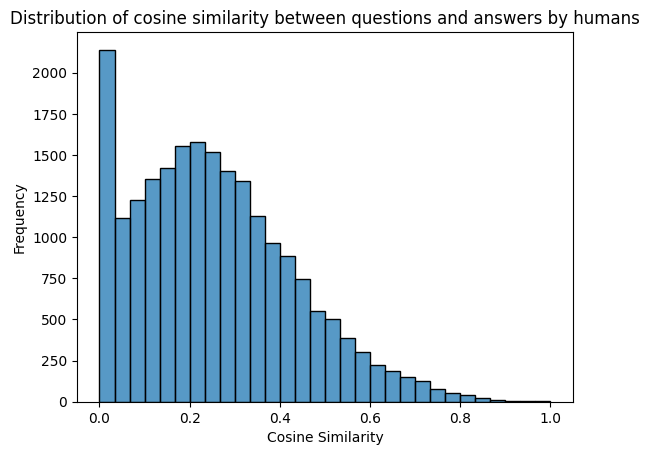

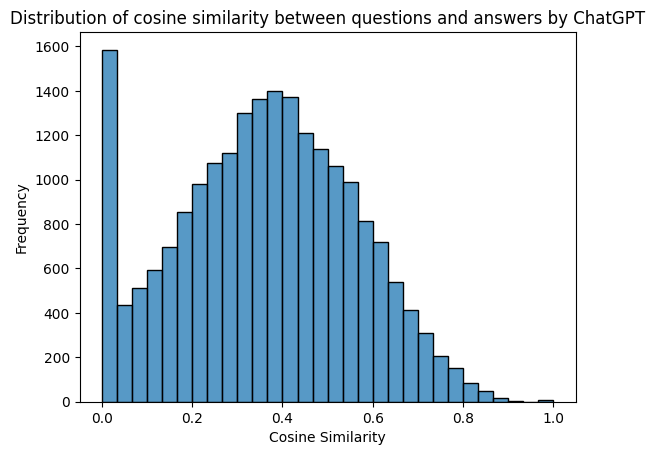

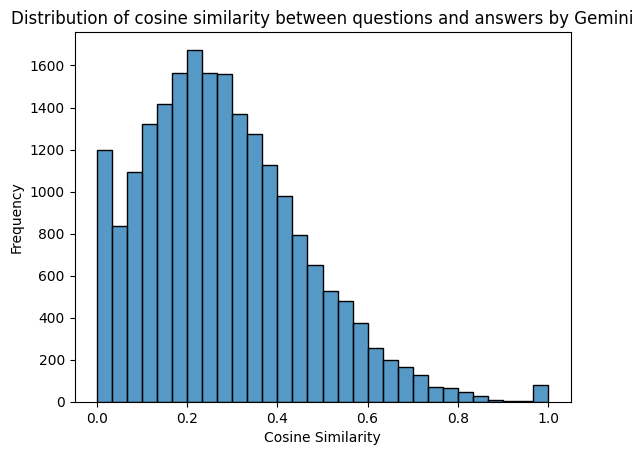

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(data = df[df['writer'] == 'human_answers'], x = 'cosine_sim_answer_question', bins=30, label='Human Answers')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by humans')
plt.show()

sns.histplot(data = df[df['writer'] == 'chatgpt_answers'], x = 'cosine_sim_answer_question', bins=30, label='ChatGPT Answers')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by ChatGPT')
plt.show()

sns.histplot(data = df[df['writer'] == 'gemini_answers'], x = 'cosine_sim_answer_question', bins=30, label='Gemini Answers')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by Gemini')
plt.show()

In [13]:
df_human_answers = df[df['writer'] == 'human_answers'].copy()
df_gpt_answers = df[df['writer'] == 'chatgpt_answers'].copy()
df_gemini_answers = df[df['writer'] == 'gemini_answers'].copy()

df_human_answers.loc[:, 'answer_symbols_only'] = df_human_answers['answer_clean'].str.replace(r'[A-Za-z0-9\s]', '', regex=True)
df_gpt_answers.loc[:, 'answer_symbols_only'] = df_gpt_answers['answer_clean'].str.replace(r'[A-Za-z0-9\s]', '', regex=True)
df_gemini_answers.loc[:, 'answer_symbols_only'] = df_gemini_answers['answer_clean'].str.replace(r'[A-Za-z0-9\s]', '', regex=True)


In [14]:
from collections import Counter

char_counter_human = Counter()
char_counter_gpt = Counter()
char_counter_gemini = Counter()

for q in df_human_answers['answer_symbols_only']:
    char_counter_human.update(q)

for q in df_gpt_answers['answer_symbols_only']:
    char_counter_gpt.update(q)

for q in df_gemini_answers['answer_symbols_only']:
    char_counter_gemini.update(q)

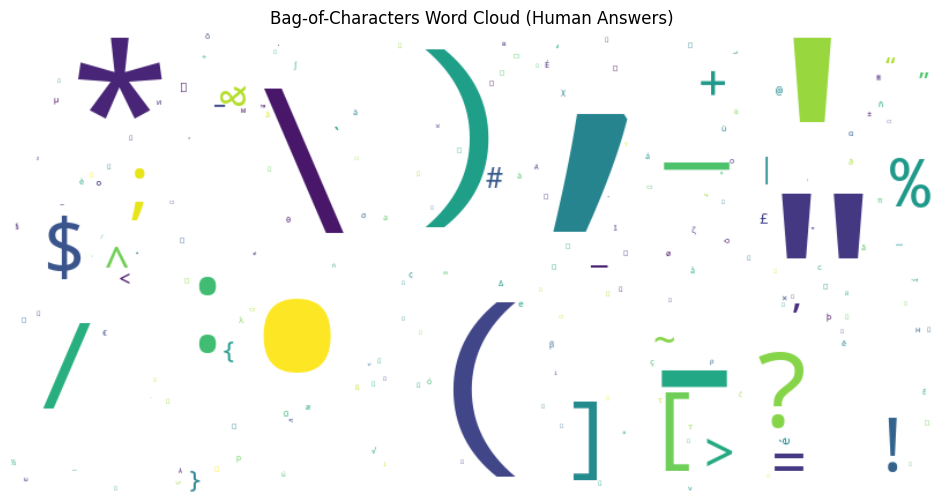

In [15]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(char_counter_human)
plt.figure(figsize=(15, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Bag-of-Characters Word Cloud (Human Answers)")
plt.show()

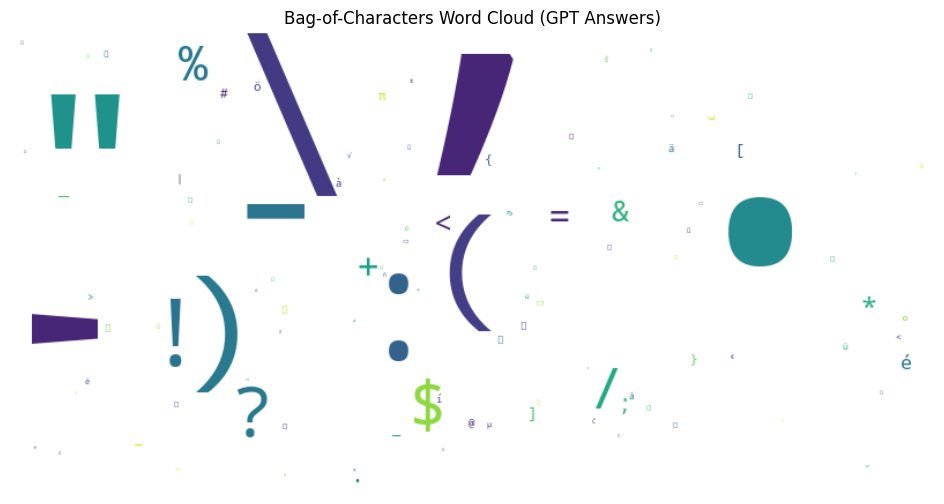

In [16]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(char_counter_gpt)
plt.figure(figsize=(15, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Bag-of-Characters Word Cloud (GPT Answers)")
plt.show()

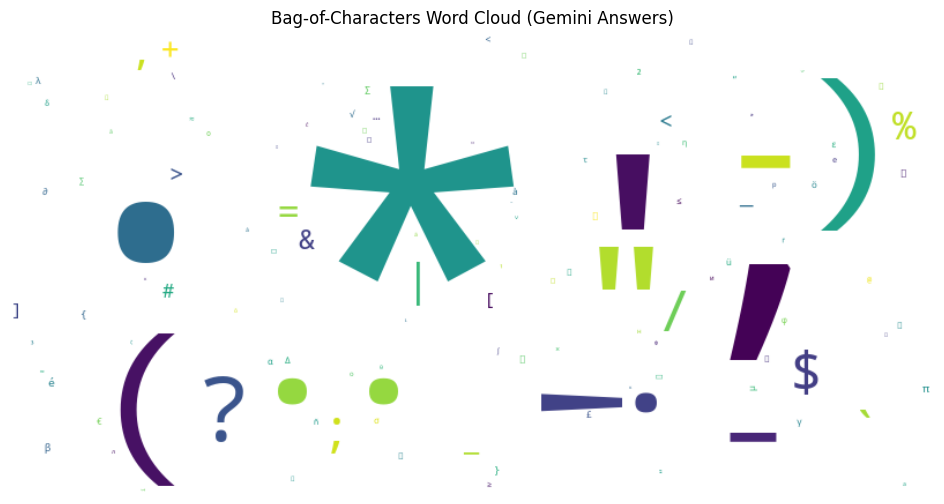

In [17]:
from wordcloud import WordCloud
char_counter_gemini.most_common(20)
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(char_counter_gemini)
plt.figure(figsize=(15, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Bag-of-Characters Word Cloud (Gemini Answers)")
plt.show()

In [18]:
df.head()

,source,question,answer,writer,question_clean,answer_clean,cosine_sim_answer_question
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...,0.217907
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens...",0.019536
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...,0.084541
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...,0.142301
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ...",0.126231


In [19]:
df['no punct'] = df['answer_clean']
df.drop(columns=['answer_clean'], inplace=True)

In [20]:
df['answer_length'] = df['answer'].apply(lambda x: len(x.split()))
df['question_length'] = df['question'].apply(lambda x: len(x.split()))

In [21]:
df.head()

,source,question,answer,writer,question_clean,cosine_sim_answer_question,no punct,answer_length,question_length
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,0.217907,Imagine you have a toy train. Some toy trains ...,150,23
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,0.019536,"In conjunction with the software , the IR sens...",498,38
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,0.084541,The authorities in the case would have gathere...,129,44
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,0.142301,Emulators are programs that allow a computer t...,160,53
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...",0.126231,"In the US , pretty much all blacks originally ...",650,24


In [22]:
import string   
def preprocess_text(
    text,
    stopwords,
    lemmatizer,
    stemmer=None
):
    if not isinstance(text, str):
        return ""

    # lowercase
    text = text.lower()

    # remove urls & emails
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", text)

    # remove punctuation & extra spaces
    text = re.sub(f"[{string.punctuation}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords & short tokens
    tokens = [t for t in tokens if t not in stopwords and len(t) > 1]

    # lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # optional stemming
    if stemmer:
        tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)


In [23]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_answer(text):
    return preprocess_text(
        text,
        stopwords=stop_words,
        lemmatizer=lemmatizer
    )

df['cleaned_answer'] = df['answer'].apply(clean_answer)


In [24]:
df.head()

,source,question,answer,writer,question_clean,cosine_sim_answer_question,no punct,answer_length,question_length,cleaned_answer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,0.217907,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,0.019536,"In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,0.084541,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,0.142301,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...",0.126231,"In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...


In [25]:
#vectorizer = TfidfVectorizer(stop_words='english')

#tfidf_matrix = vectorizer.fit_transform(df['cleaned_answer'])

#tfidf_scores = tfidf_matrix.mean(axis=1)

#df['tfidf_score'] = np.array(tfidf_scores).flatten()

#df.head()


In [26]:
df.groupby('writer')['answer_length'].mean().reset_index()

,writer,answer_length
0,chatgpt_answers,186.048476
1,gemini_answers,203.964260
2,human_answers,350.887667


In [27]:
#sns.histplot(data=df, x='tfidf_score', hue='writer', element='step', stat='density', common_norm=False)
#plt.title('Distribution of TF-IDF Scores by Writer')
#plt.show()


In [28]:
df['answer_length'].nunique()

1509

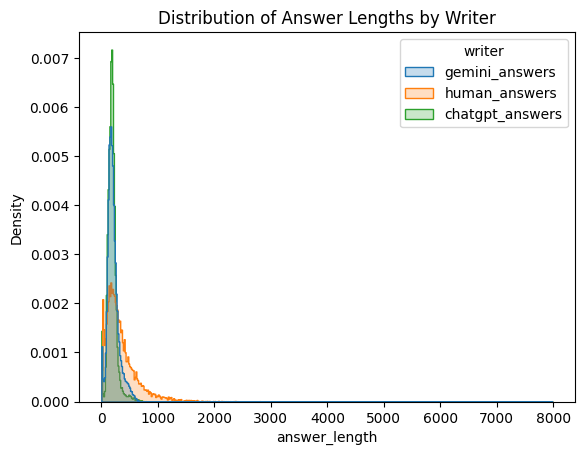

In [29]:
sns.histplot(data=df, x='answer_length', hue='writer', element='step', stat='density', common_norm=False)
plt.title('Distribution of Answer Lengths by Writer')
plt.show()

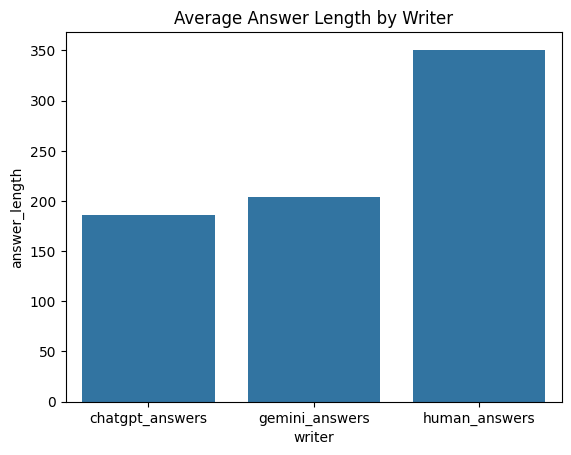

In [30]:
average_answer_len_each_writer = df.groupby('writer')['answer_length'].mean().reset_index()
graph = sns.barplot(x='writer', y='answer_length', data=average_answer_len_each_writer)
plt.title('Average Answer Length by Writer')
plt.show()


In [31]:
#sns.regplot(data=df, x='answer_length', y='tfidf_score')
#plt.title('Answer Length vs. TF-IDF Score by Writer')  
#plt.show()

In [32]:
df.head()

,source,question,answer,writer,question_clean,cosine_sim_answer_question,no punct,answer_length,question_length,cleaned_answer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,0.217907,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,0.019536,"In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,0.084541,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,0.142301,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...",0.126231,"In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...


In [33]:
#decition tree classifier eda columns: cosine_sim_answer_question, answer_length
clf = DecisionTreeClassifier(random_state=42)
X = df[['cosine_sim_answer_question', 'answer_length']]
y = df['writer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
#results
y_pred = clf.predict(X_test)
#confution matrix with title: decision tree eda features: cosine_sim_answer_question, answer_length
from sklearn.metrics import confusion_matrix, classification_report
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print("Confusion matrix eda features:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1968 1364  806]
 [1378 1659 1182]
 [ 751 1024 2437]]
Confusion matrix eda features:
                 precision    recall  f1-score   support

chatgpt_answers       0.48      0.48      0.48      4138
 gemini_answers       0.41      0.39      0.40      4219
  human_answers       0.55      0.58      0.56      4212

       accuracy                           0.48     12569
      macro avg       0.48      0.48      0.48     12569
   weighted avg       0.48      0.48      0.48     12569



In [34]:
texts = df['answer'].tolist()
vectorizer = TfidfVectorizer(stop_words='english')
vec = vectorizer.fit(texts)

In [35]:
df['tfidf_vectorizer'] =df['answer'].apply(lambda x: vec.transform([x]))

In [36]:
df['tfidf_vectorizer'].head()

0    <Compressed Sparse Row sparse matrix of dtype ...
1    <Compressed Sparse Row sparse matrix of dtype ...
2    <Compressed Sparse Row sparse matrix of dtype ...
3    <Compressed Sparse Row sparse matrix of dtype ...
4    <Compressed Sparse Row sparse matrix of dtype ...
Name: tfidf_vectorizer, dtype: object

In [37]:
X = vectorizer.fit_transform(df["cleaned_answer"])

classes = df["writer"].unique()
centroids_tf = {}

for c in classes:
    mask = (df["writer"].values == c)
    centroids_tf[c] = X[mask].mean(axis=0)   

In [38]:
centroids_tf

{'gemini_answers': matrix([[1.67032705e-04, 1.12001948e-03, 3.06920368e-05, ...,
          0.00000000e+00, 1.01697426e-05, 0.00000000e+00]],
        shape=(1, 75605)),
 'human_answers': matrix([[7.05168435e-04, 4.42623472e-03, 6.27927595e-05, ...,
          6.54086455e-06, 5.37702802e-06, 7.67360774e-06]],
        shape=(1, 75605)),
 'chatgpt_answers': matrix([[2.80217704e-04, 1.55891788e-03, 2.58890712e-05, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
        shape=(1, 75605))}

In [39]:
df.head()

,source,question,answer,writer,question_clean,cosine_sim_answer_question,no punct,answer_length,question_length,cleaned_answer,tfidf_vectorizer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,0.217907,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...,<Compressed Sparse Row sparse matrix of dtype ...
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,0.019536,"In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...,<Compressed Sparse Row sparse matrix of dtype ...
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,0.084541,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...,<Compressed Sparse Row sparse matrix of dtype ...
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,0.142301,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...,<Compressed Sparse Row sparse matrix of dtype ...
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...",0.126231,"In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...,<Compressed Sparse Row sparse matrix of dtype ...


In [40]:
from scipy.sparse import vstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# X is your TF-IDF matrix: X = vectorizer.fit_transform(df["cleaned_answer"])
# centroids is dict: centroids[c] = X[mask].mean(axis=0)

classes = list(centroids_tf.keys())

# Stack centroids into a matrix: (n_classes, n_features)
C = vstack([csr_matrix(centroids_tf[c]) for c in classes]).tocsr()

# Cosine similarity: (n_rows, n_classes)
S = cosine_similarity(X, C)   # works with sparse matrices

# Save to df
for j, c in enumerate(classes):
    df[f"cos_to_{c}_tfidf"] = S[:, j]

df["pred_writer"] = [classes[i] for i in S.argmax(axis=1)]



In [41]:
df.head()

,source,question,answer,writer,question_clean,cosine_sim_answer_question,no punct,answer_length,question_length,cleaned_answer,tfidf_vectorizer,cos_to_gemini_answers_tfidf,cos_to_human_answers_tfidf,cos_to_chatgpt_answers_tfidf,pred_writer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,0.217907,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...,<Compressed Sparse Row sparse matrix of dtype ...,0.223619,0.134160,0.132219,gemini_answers
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,0.019536,"In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...,<Compressed Sparse Row sparse matrix of dtype ...,0.104562,0.121780,0.095460,human_answers
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,0.084541,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...,<Compressed Sparse Row sparse matrix of dtype ...,0.038772,0.068103,0.089330,chatgpt_answers
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,0.142301,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...,<Compressed Sparse Row sparse matrix of dtype ...,0.064589,0.094798,0.140516,chatgpt_answers
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...",0.126231,"In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...,<Compressed Sparse Row sparse matrix of dtype ...,0.097590,0.164052,0.153385,human_answers


In [42]:
#tf idf accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(df['writer'], df['pred_writer'])  
print(f'TF-IDF Classifier Accuracy: {accuracy:.4f}')


TF-IDF Classifier Accuracy: 0.8401


In [43]:
df.columns

Index(['source', 'question', 'answer', 'writer', 'question_clean',
       'cosine_sim_answer_question', 'no punct', 'answer_length',
       'question_length', 'cleaned_answer', 'tfidf_vectorizer',
       'cos_to_gemini_answers_tfidf', 'cos_to_human_answers_tfidf',
       'cos_to_chatgpt_answers_tfidf', 'pred_writer'],
      dtype='object')

In [44]:
df_for_tree = df[['cosine_sim_answer_question','writer','answer_length','cos_to_gemini_answers_tfidf', 'cos_to_human_answers_tfidf','cos_to_chatgpt_answers_tfidf']]

In [45]:
X = df_for_tree.drop('writer', axis=1)
y = df_for_tree['writer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[3427  314  397]
 [ 335 3616  268]
 [ 372  276 3564]]
                 precision    recall  f1-score   support

chatgpt_answers       0.83      0.83      0.83      4138
 gemini_answers       0.86      0.86      0.86      4219
  human_answers       0.84      0.85      0.84      4212

       accuracy                           0.84     12569
      macro avg       0.84      0.84      0.84     12569
   weighted avg       0.84      0.84      0.84     12569



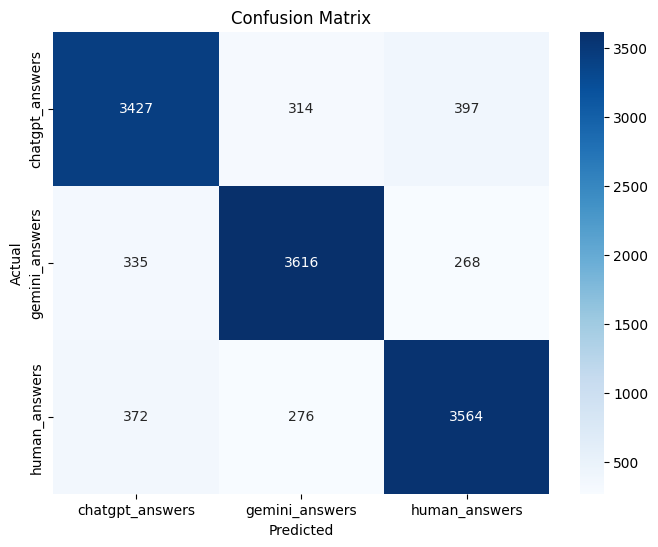

In [46]:
#display confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [47]:
#display decision tree
#from sklearn.tree import plot_tree
#plt.figure(figsize=(20,10))
#plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
#plt.title('Decision Tree')
#plt.show()


In [48]:
df.describe()

,cosine_sim_answer_question,answer_length,question_length,cos_to_gemini_answers_tfidf,cos_to_human_answers_tfidf,cos_to_chatgpt_answers_tfidf
count,62845.000000,62845.000000,62845.000000,62845.000000,62845.000000,62845.000000
mean,0.299355,247.072862,32.751722,0.110260,0.112435,0.108230
std,0.189402,211.900234,14.580585,0.077769,0.042984,0.041912
min,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,0.155382,141.000000,23.000000,0.056973,0.084303,0.080613
50%,0.284146,193.000000,36.000000,0.085789,0.109843,0.106167
75%,0.425259,275.000000,45.000000,0.143147,0.138776,0.134672
max,1.000000,7980.000000,54.000000,0.486229,0.362174,0.326167


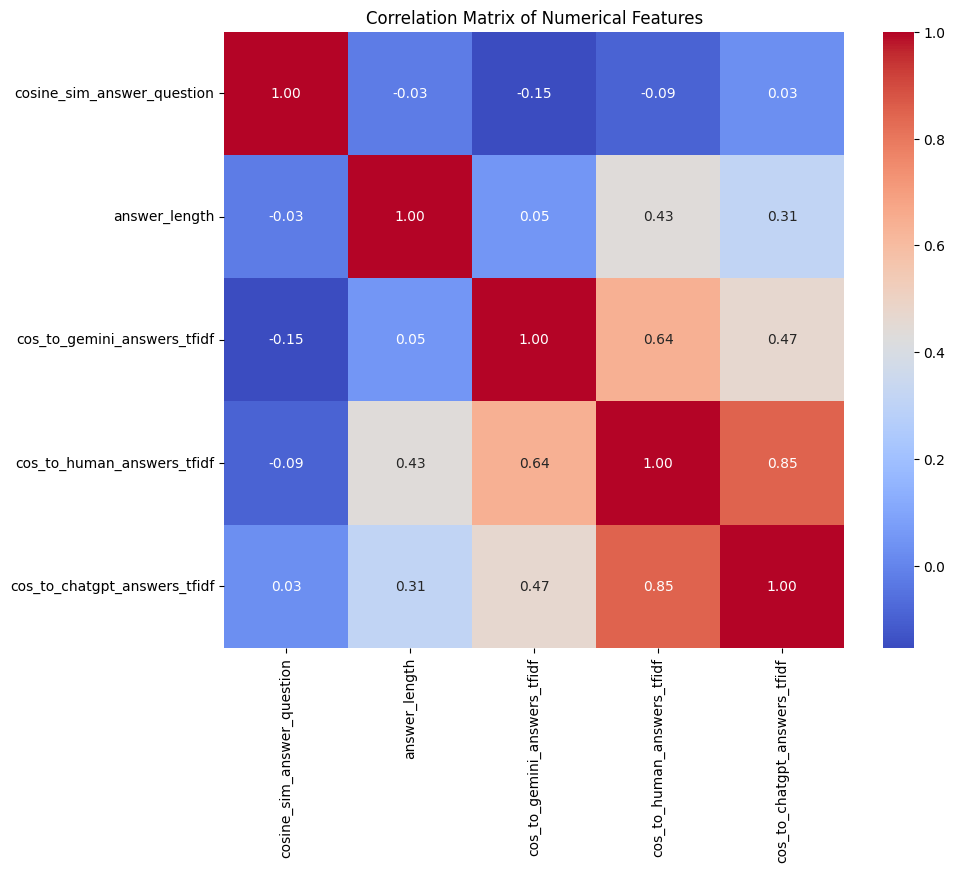

In [49]:
#designed heatmaps for the correlation between the numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = df[['cosine_sim_answer_question', 'answer_length', 'cos_to_gemini_answers_tfidf', 'cos_to_human_answers_tfidf', 'cos_to_chatgpt_answers_tfidf']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


In [50]:
#using Sbert model to compute cosine similarity and predict writer based on that
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['answer'].tolist(), convert_to_tensor=True)
df['sbert_embedding'] = list(embeddings.cpu().numpy())
#the above line takes a long time to run
#sbert is a vector represnting each answer, with meaning


c:\Users\gavri\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gavri\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not insta

In [51]:
df.head()

,source,question,answer,writer,question_clean,cosine_sim_answer_question,no punct,answer_length,question_length,cleaned_answer,tfidf_vectorizer,cos_to_gemini_answers_tfidf,cos_to_human_answers_tfidf,cos_to_chatgpt_answers_tfidf,pred_writer,sbert_embedding
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,0.217907,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...,<Compressed Sparse Row sparse matrix of dtype ...,0.223619,0.134160,0.132219,gemini_answers,"[0.11626955, -0.05996878, 0.096896686, 0.09030..."
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,0.019536,"In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...,<Compressed Sparse Row sparse matrix of dtype ...,0.104562,0.121780,0.095460,human_answers,"[-0.03816155, 0.0038187956, -0.09561434, -0.07..."
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,0.084541,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...,<Compressed Sparse Row sparse matrix of dtype ...,0.038772,0.068103,0.089330,chatgpt_answers,"[-0.003024913, 0.12723258, -0.0057569086, -0.0..."
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,0.142301,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...,<Compressed Sparse Row sparse matrix of dtype ...,0.064589,0.094798,0.140516,chatgpt_answers,"[-0.011908867, 0.036533497, 0.047002584, -0.12..."
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...",0.126231,"In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...,<Compressed Sparse Row sparse matrix of dtype ...,0.097590,0.164052,0.153385,human_answers,"[-0.0073087895, 0.031058116, -0.020351341, 0.0..."


In [57]:
#using logistic regression to classify the writer based on sbert embeddings
from sklearn.linear_model import LogisticRegression
X = np.vstack(df['sbert_embedding'].values)
y = df['writer']
X = X / np.linalg.norm(X, axis=1, keepdims=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
logreg = LogisticRegression(
    max_iter=2000,
    solver="saga",
    C=0.7,                
    class_weight={'human_answers': 1.6, 'chatgpt_answers': 1, 'gemini_answers': 1},
    n_jobs=-1
)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)


In [58]:
#evaluate logistic regression model
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[3523  136  479]
 [ 123 3761  335]
 [ 235  144 3833]]
                 precision    recall  f1-score   support

chatgpt_answers       0.91      0.85      0.88      4138
 gemini_answers       0.93      0.89      0.91      4219
  human_answers       0.82      0.91      0.87      4212

       accuracy                           0.88     12569
      macro avg       0.89      0.88      0.88     12569
   weighted avg       0.89      0.88      0.88     12569



In [59]:
# Compute centroids for each writer

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
writers = df['writer'].unique()
centroids = {}
for writer in writers:
    writer_embeddings = np.array(df[df['writer'] == writer]['sbert_embedding'].tolist())
    centroids[writer] = np.mean(writer_embeddings, axis=0)

# Compute cosine similarity to centroids

def compute_cosine_to_centroids(embedding):
    similarities = {}
    for writer, centroid in centroids.items():
        sim = cosine_similarity([embedding], [centroid])[0][0]
        similarities[f'cos_to_{writer}'] = sim
    return similarities

df_centroid_sims = df['sbert_embedding'].apply(compute_cosine_to_centroids)
df_centroid_sims_df = pd.DataFrame(df_centroid_sims.tolist())
df = pd.concat([df, df_centroid_sims_df], axis=1)

# Predict writer based on highest cosine similarity to centroids

centroid_cols = [f'cos_to_{writer}' for writer in writers]
df['pred_writer_sbert'] = df[centroid_cols].idxmax(axis=1).str.replace('cos_to_', '')
df.head()



,source,question,answer,writer,question_clean,cosine_sim_answer_question,no punct,answer_length,question_length,cleaned_answer,tfidf_vectorizer,cos_to_gemini_answers_tfidf,cos_to_human_answers_tfidf,cos_to_chatgpt_answers_tfidf,pred_writer,sbert_embedding,cos_to_gemini_answers,cos_to_human_answers,cos_to_chatgpt_answers,pred_writer_sbert
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,gemini_answers,Why do some animals become trained more easily...,0.217907,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...,<Compressed Sparse Row sparse matrix of dtype ...,0.223619,0.134160,0.132219,gemini_answers,"[0.11626955, -0.05996878, 0.096896686, 0.09030...",0.441160,0.311123,0.313500,gemini_answers
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,0.019536,"In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...,<Compressed Sparse Row sparse matrix of dtype ...,0.104562,0.121780,0.095460,human_answers,"[-0.03816155, 0.0038187956, -0.09561434, -0.07...",0.261832,0.209857,0.206521,gemini_answers
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,0.084541,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...,<Compressed Sparse Row sparse matrix of dtype ...,0.038772,0.068103,0.089330,chatgpt_answers,"[-0.003024913, 0.12723258, -0.0057569086, -0.0...",0.089130,0.199492,0.188894,human_answers
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,0.142301,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...,<Compressed Sparse Row sparse matrix of dtype ...,0.064589,0.094798,0.140516,chatgpt_answers,"[-0.011908867, 0.036533497, 0.047002584, -0.12...",0.310403,0.370552,0.433791,chatgpt_answers
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...",0.126231,"In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...,<Compressed Sparse Row sparse matrix of dtype ...,0.097590,0.164052,0.153385,human_answers,"[-0.0073087895, 0.031058116, -0.020351341, 0.0...",0.308838,0.388827,0.300131,human_answers


In [60]:
#sbert accuracy
from sklearn.metrics import classification_report, confusion_matrix
cm_sbert = confusion_matrix(df['writer'], df['pred_writer_sbert'])
print("Confusion Matrix (SBERT):")
print(cm_sbert)
print("Classification Report (SBERT):")
print(classification_report(df['writer'], df['pred_writer_sbert']))





Confusion Matrix (SBERT):
[[16530  1240  3230]
 [ 2178 17080  1587]
 [ 3913  2569 14518]]
Classification Report (SBERT):
                 precision    recall  f1-score   support

chatgpt_answers       0.73      0.79      0.76     21000
 gemini_answers       0.82      0.82      0.82     20845
  human_answers       0.75      0.69      0.72     21000

       accuracy                           0.77     62845
      macro avg       0.77      0.77      0.77     62845
   weighted avg       0.77      0.77      0.77     62845



In [61]:
test_data = pd.read_csv("50_questions_ido.csv")
test_data.head() 

,question,answer,writer
0,What does success mean to you?,I usually think about success in a very practi...,human
1,What does success mean to you?,Human reasoning tends to operate through narra...,gemini
2,What does success mean to you?,"When thinking about meaning, I often find that...",chatgpt
3,Is uncertainty something to avoid or accept?,Success means being able to stand behind your ...,human
4,Is uncertainty something to avoid or accept?,Human reasoning tends to operate through narra...,gemini


In [62]:
#testing on logistic regression model with sbert embeddings on new test data
test_embeddings = model.encode(test_data['answer'].tolist(), convert_to_tensor=True)
test_data['sbert_embedding'] = list(test_embeddings.cpu().numpy())
X_test = np.array(test_data['sbert_embedding'].tolist())
X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)
y_pred = logreg.predict(X_test)
test_data['predicted_writer'] = y_pred
#accuracy on test data
#evaluate logistic regression model



In [63]:
y_pred

array(['gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'chatgpt_answers', 'chatgpt_answers', 'gemini_answers',
       'gemini_answers', 'chatgpt_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'chatgpt_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'chatgpt_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'chatgpt_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'chatgpt_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_answers', 'gemini_answers', 'gemini_answers',
       'gemini_an

In [64]:
test_data['writer'] = test_data['writer'].str.replace('human', 'human_answers')
test_data['writer'] = test_data['writer'].str.replace('chatgpt', 'chatgpt_answers')
test_data['writer'] = test_data['writer'].str.replace('gemini', 'gemini_answers')

In [65]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(test_data['writer'], y_pred))
print(classification_report(test_data['writer'], y_pred))

[[ 0 20  0]
 [ 6 14  0]
 [ 2 18  0]]
                 precision    recall  f1-score   support

chatgpt_answers       0.00      0.00      0.00        20
 gemini_answers       0.27      0.70      0.39        20
  human_answers       0.00      0.00      0.00        20

       accuracy                           0.23        60
      macro avg       0.09      0.23      0.13        60
   weighted avg       0.09      0.23      0.13        60



c:\Users\gavri\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gavri\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gavri\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [89]:
test2_data = pd.read_csv("50_with_all_human_answers_unique.csv")
test2_data.dropna(inplace=True)
test2_data.head()

,question,chatgpt answer,gemini answer,human answer
10,What are some easy meals that are actually hea...,I live on “mix and match” meals because I’m no...,"I am not a chef, I just need fuel. My go-to is...",Honestly I feel like people already know the a...
11,Can you explain logistic regression in simple ...,Logistic regression is basically a “yes/no” pr...,"So, despite the name 'regression,' it's actual...","To be real, distractions ruin everything. Phon..."
12,How do I get over a breakup?,"I hate how cliché this sounds, but time + stru...","Oh honey, I'm sorry. It physically hurts, does...",I think this is more mental then people think....
13,How can I be more confident socially?,"Confidence isn’t a personality trait, it’s usu...",'Fake it 'til you make it' is real advice. Sta...,I think people blame outside things too much i...
14,What’s the best way to learn Python?,If you want to actually learn Python (not just...,Stop watching tutorials and start building. Tu...,Most people fail at this because they give up ...


In [90]:
test2_data.shape

(39, 4)

In [91]:
# clean column names (remove hidden spaces)
test2_data.columns = test2_data.columns.str.strip()

# melt correctly
test2_data = test2_data.melt(
    id_vars=["question"],
    value_vars=["human answer", "chatgpt answer", "gemini answer"],
    var_name="writer",
    value_name="answer"
)

# drop missing answers
test2_data = test2_data.dropna(subset=["answer"])

# rename writer labels to match training
test2_data["writer"] = test2_data["writer"].replace({
    "human answer": "human_answers",
    "chatgpt answer": "chatgpt_answers",
    "gemini answer": "gemini_answers"
})


In [92]:
test2_data.shape

(117, 3)

In [93]:
#testing on logistic regression model with sbert embeddings on new test data
test2_embeddings = model.encode(test2_data['answer'].tolist(), convert_to_tensor=True)
test2_data['sbert_embedding'] = list(test2_embeddings.cpu().numpy())
X_test = np.array(test2_data['sbert_embedding'].tolist())
X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)
y_pred = logreg.predict(X_test)
test2_data['predicted_writer'] = y_pred
#accuracy on test data
#evaluate logistic regression model



In [94]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(test2_data['writer'], y_pred))
print(classification_report(test2_data['writer'], y_pred))

[[ 1 29  9]
 [ 1 26 12]
 [ 1 36  2]]
                 precision    recall  f1-score   support

chatgpt_answers       0.33      0.03      0.05        39
 gemini_answers       0.29      0.67      0.40        39
  human_answers       0.09      0.05      0.06        39

       accuracy                           0.25       117
      macro avg       0.24      0.25      0.17       117
   weighted avg       0.24      0.25      0.17       117

